# Support Vector Machine


<center>

__Modelación del Aprendizaje con Inteligencia Artificial__

_GPO 302_

Actividad 3 _Redes Neuronales (Keras)_


Prof. Jorge Adolfo Ramírez Uresti




Diego A. Parra Ruíz - - - A01801026
</center>

## Librería

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix



## Importación de Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_link = "/Data/data_wavelet.txt"
col_names = ["variance", "skewness", "curtosis", "entropy", "class"]

bankdata = pd.read_csv(data_link, names=col_names, sep=",", header=None)
bankdata.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


## Métricas del Dataset

In [ ]:
bankdata['class'].unique()

array([0, 1])

In [ ]:
bankdata.shape

(1372, 5)

In [ ]:
bankdata['class'].value_counts()
bankdata['class'].value_counts(normalize=True)

,proportion
class,
0,0.555394
1,0.444606


### Métricas de Columna Clase

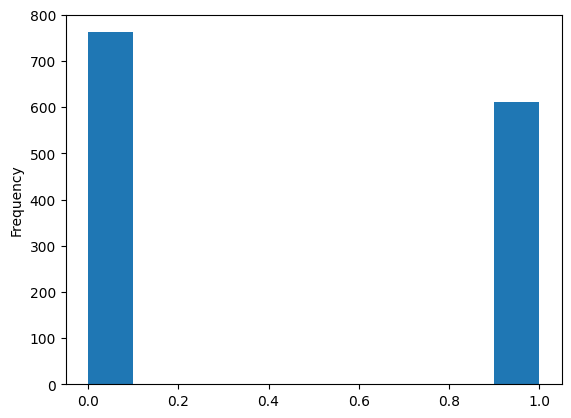

In [ ]:
bankdata['class'].plot.hist();

In [ ]:
bankdata.describe().T

,count,mean,std,min,25%,50%,75%,max
variance,1372.0,0.433735,2.842763,-7.0421,-1.773000,0.49618,2.821475,6.8248
skewness,1372.0,1.922353,5.869047,-13.7731,-1.708200,2.31965,6.814625,12.9516
curtosis,1372.0,1.397627,4.310030,-5.2861,-1.574975,0.61663,3.179250,17.9274
entropy,1372.0,-1.191657,2.101013,-8.5482,-2.413450,-0.58665,0.394810,2.4495
class,1372.0,0.444606,0.497103,0.0000,0.000000,0.00000,1.000000,1.0000


### Histogramas de Columnas

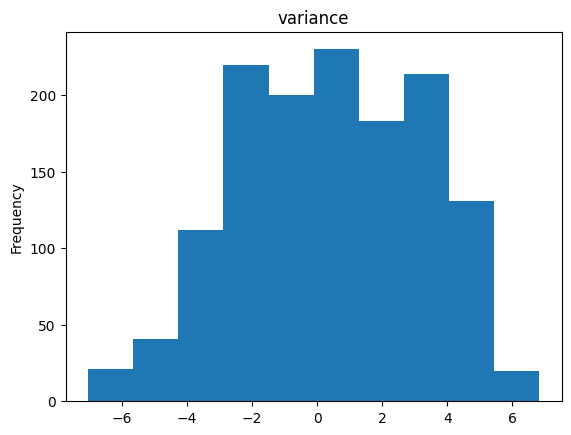

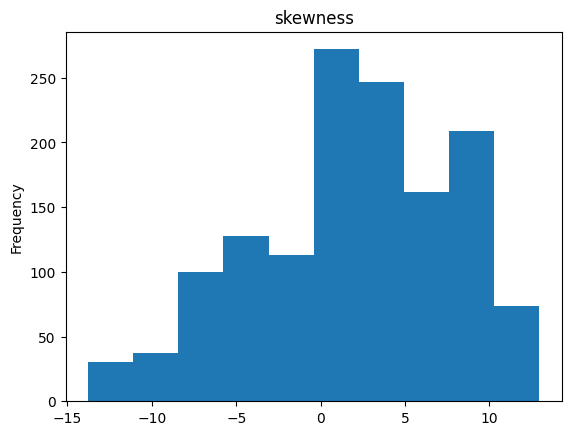

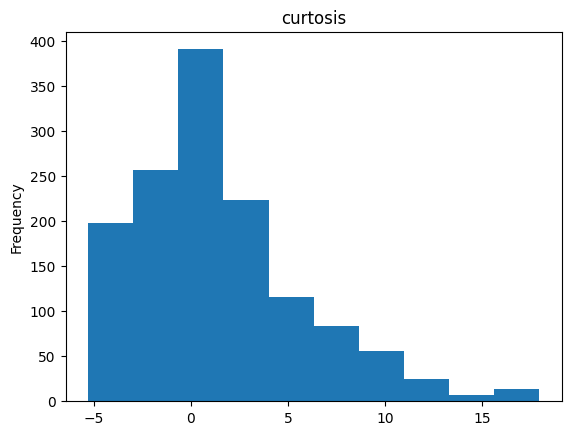

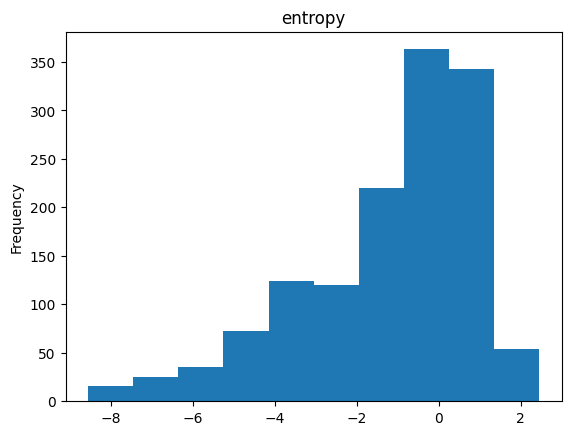

In [ ]:
for col in bankdata.columns[:-1]:
    plt.title(col)
    bankdata[col].plot.hist() #plotting the histogram with Pandas
    plt.show();

### Scatter Plots de Atributos

variance skewness


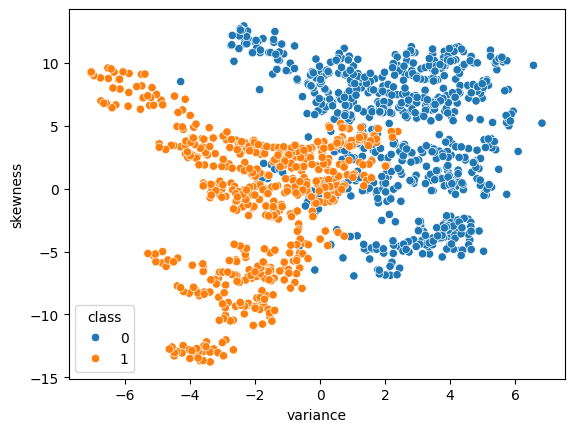

variance curtosis


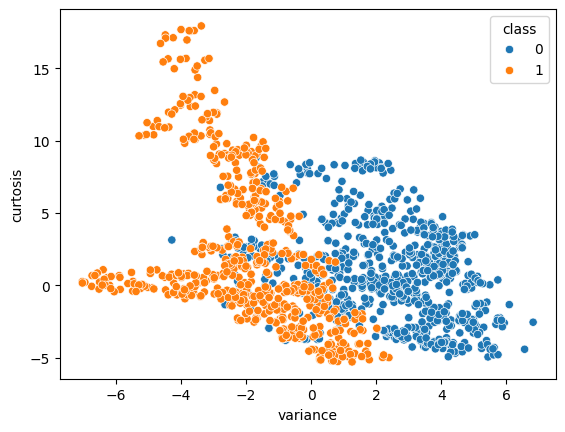

variance entropy


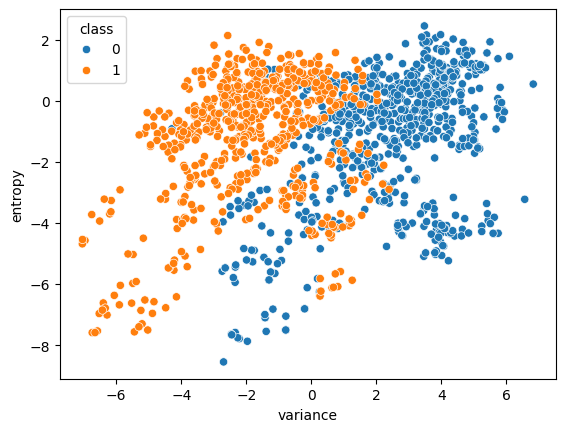

skewness variance


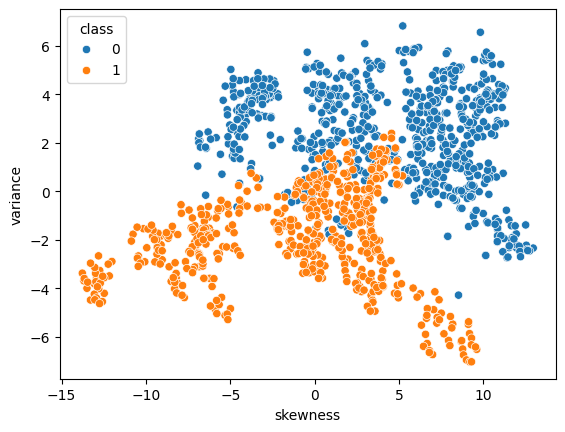

skewness curtosis


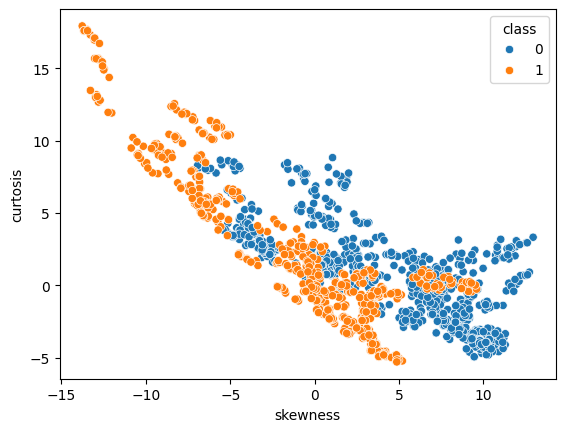

skewness entropy


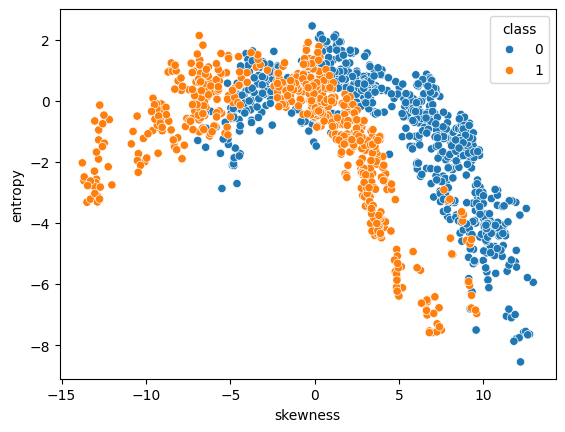

curtosis variance


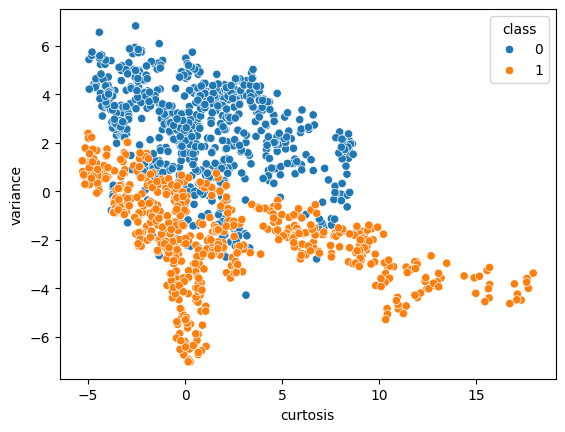

curtosis skewness


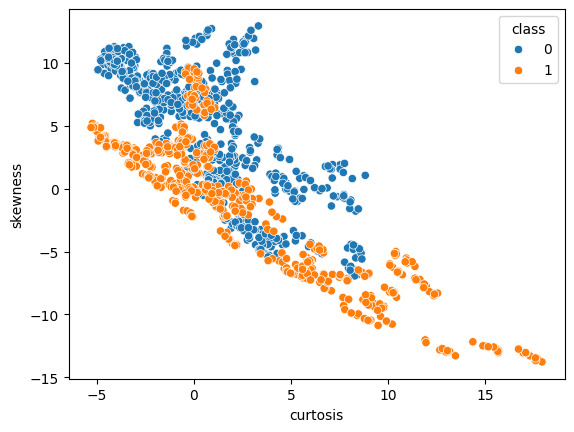

curtosis entropy


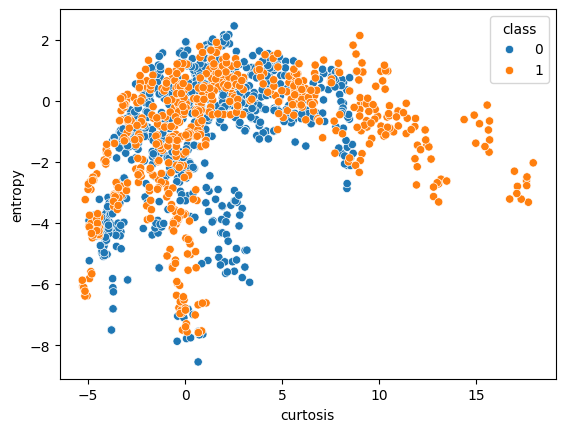

entropy variance


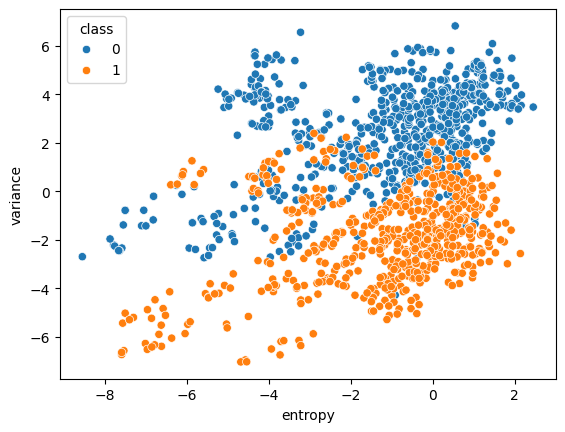

entropy skewness


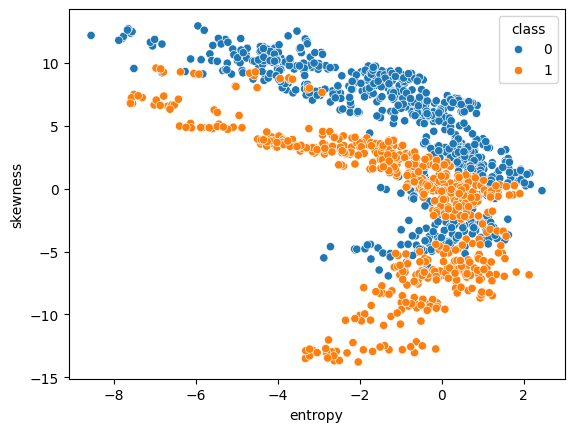

entropy curtosis


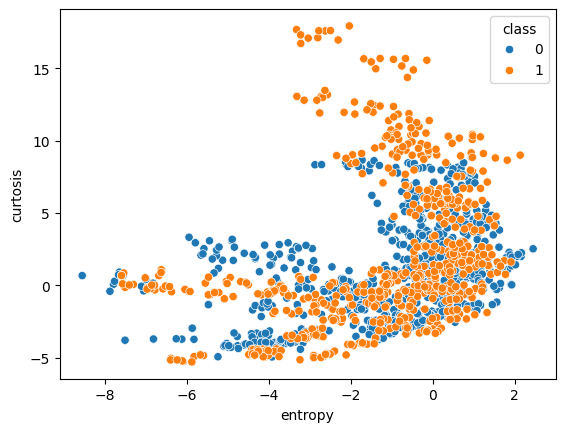

In [ ]:
for feature_1 in bankdata.columns[:-1]:
    for feature_2 in bankdata.columns[:-1]:
        if feature_1 != feature_2: # test if the features are different
            print(feature_1, feature_2) # prints features names
            sns.scatterplot(x=feature_1, y=feature_2, data=bankdata, hue='class') # plots each feature points with its color depending on the class column value
            plt.show();

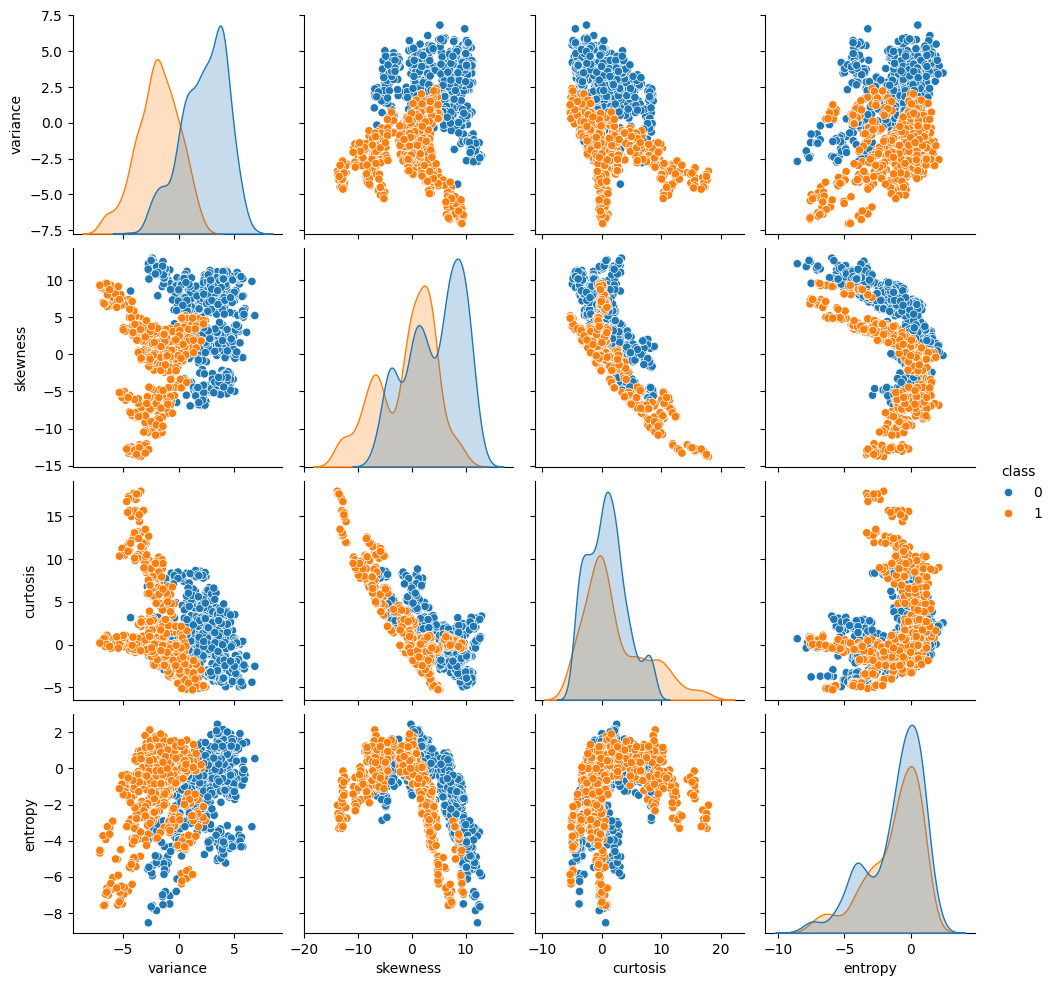

In [ ]:
sns.pairplot(bankdata, hue='class');

## Split de Datos para Entrenamiento

In [ ]:
y = bankdata['class']
X = bankdata.drop('class', axis=1) # axis=1 means dropping from the column axis

SEED = 42

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = SEED)

xtrain_samples = X_train.shape[0]
xtest_samples = X_test.shape[0]

print(f'There are {xtrain_samples} samples for training and {xtest_samples} samples for testing.')

There are 1097 samples for training and 275 samples for testing.


## Creación de SVC

In [ ]:
svc = SVC(kernel='linear')
svc.fit(X_train, y_train)

SVC(kernel='linear')

### Predicción de Test con SVC

In [ ]:
y_pred = svc.predict(X_test)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       148
           1       0.98      0.98      0.98       127

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



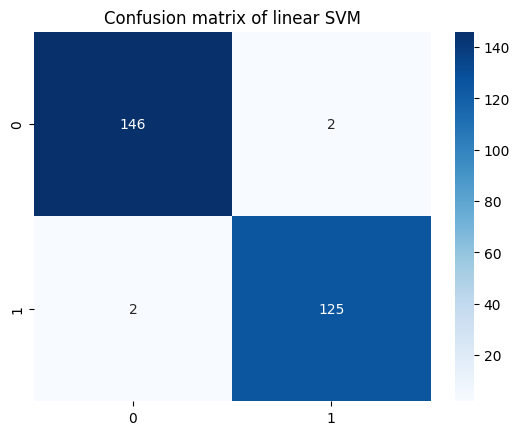

In [ ]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues').set_title('Confusion matrix of linear SVM') # fmt='d' formats the numbers as digits, which means integers

print(classification_report(y_test,y_pred))

### Predicción de Train con SVC

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       614
           1       0.98      0.99      0.99       483

    accuracy                           0.99      1097
   macro avg       0.99      0.99      0.99      1097
weighted avg       0.99      0.99      0.99      1097



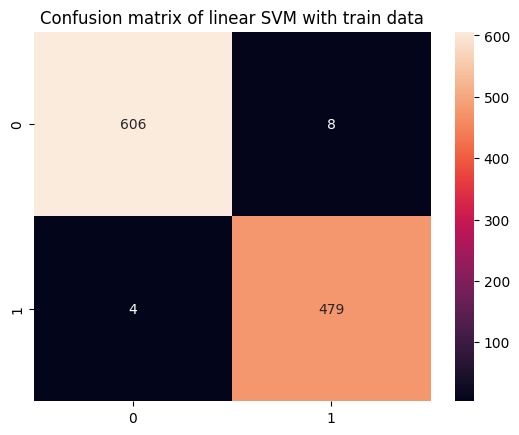

In [ ]:
y_pred_train = svc.predict(X_train)

cm_train = confusion_matrix(y_train,y_pred_train)
sns.heatmap(cm_train, annot=True, fmt='d').set_title('Confusion matrix of linear SVM with train data')

print(classification_report(y_train,y_pred_train))

## SVC con Kernel Gaussiano

In [ ]:
svc = SVC(kernel='rbf')
svc.fit(X_train, y_train)

SVC()

### Predicción Test con SVC

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       148
           1       1.00      1.00      1.00       127

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



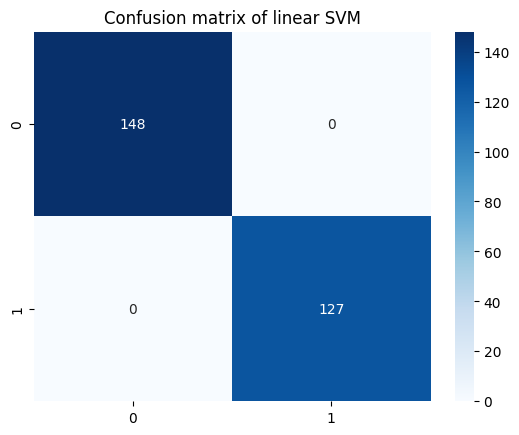

In [ ]:
y_pred = svc.predict(X_test)
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues').set_title('Confusion matrix of linear SVM') # fmt='d' formats the numbers as digits, which means integers

print(classification_report(y_test,y_pred))

### Predicción Train con SVC

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       614
           1       0.99      1.00      0.99       483

    accuracy                           1.00      1097
   macro avg       0.99      1.00      1.00      1097
weighted avg       1.00      1.00      1.00      1097



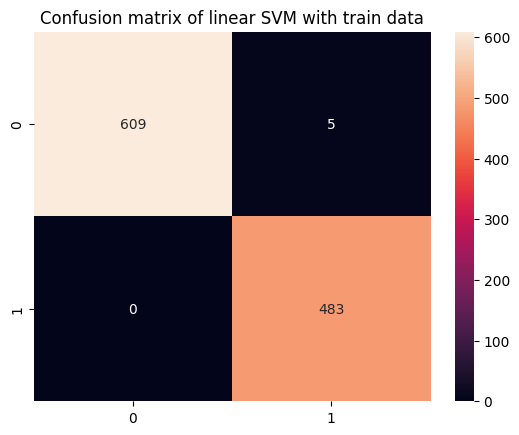

In [ ]:
y_pred_train = svc.predict(X_train)

cm_train = confusion_matrix(y_train,y_pred_train)
sns.heatmap(cm_train, annot=True, fmt='d').set_title('Confusion matrix of linear SVM with train data')

print(classification_report(y_train,y_pred_train))

##Comparación de SVC

Es posible observar que ambas máquinas de soporte vectorial, tanto la que utiliza un kernel linear como aquella con un kernel gaussiano son eefectivas para predecir los datos dentro de este modelo. Sin embargo, tal como menciona el artículo, que pueda existir un tipo de clasificador que clasifique con rangos tan eficientes como los de ambas SVM utilizadas suele ser indicio de un overfitting sobre los datos. Especialmente dado que, como fue posible observar en el pairplot del dataset, no todos los datos son evidentemente separables y aún siendo algunos como la kurtosis y la varianza linearmente separables los demás datos y sus rleaciones no siempre cuentan con el mismo patrón.

Entre los dos modelos, el modelo que mejor fue capaz de predecir el dataset fue el modelo utilizando un kernel gaussiano, pues directamente en su test no provocó ni FP ni FN, igualmente al compararlos a través de métricas como el F1_Score, Accuracy etc. el primer kernel tenía un índice de 99 % aproximadamente, mientras que el segundo tiene uno de 100%.

Es posible decir sin embargo que para generalizar, tal vez el primero, el modelo con kernel lineal sea ligeramente mejor que el modelo con kernel gaussiano, probablemente porque no genero un fitting tan específico como el segundo.